<a href="https://colab.research.google.com/github/Cheromelon/Human-annotator/blob/main/human_annotator_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets,layers,models
import os
import requests

In [ ]:
(X_train_hard,y_train_hard),(X_test_hard,y_test_hard)=datasets.cifar10.load_data()

In [ ]:
X_train_hard.shape,y_train_hard.shape
y_train_hard=y_train_hard.reshape(-1,)
y_test_hard=y_test_hard.reshape(-1,)
y_train_hard.shape,y_test_hard.shape

((50000,), (10000,))

In [ ]:
#normalization
X_train_hard=X_train_hard/255
X_test_hard=X_test_hard/255
X_train_hard,X_test_hard
X_train_hard.shape,X_test_hard.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [ ]:
classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'] #classes which are present in cifar10 dataset

In [ ]:
url  = "https://raw.githubusercontent.com/jcpeterson/cifar-10h/master/data/cifar10h-probs.npy"
path = "cifar10h-probs.npy"

if not os.path.exists(path):
    print("Downloading CIFAR-10H")
    r = requests.get(url)
    with open(path, "wb") as f:
        f.write(r.content)
    print("Done!")

raw = np.load(path)
print("CIFAR-10H shape:", raw.shape)
print("Sample row:", raw[0])
print("Sum check:", raw[0].sum())

CIFAR-10H shape: (10000, 10)
Sample row: [0.         0.01960784 0.01960784 0.94117647 0.         0.01960784
 0.         0.         0.         0.        ]
Sum check: 1.0


In [ ]:
raw[0]

array([0.        , 0.01960784, 0.01960784, 0.94117647, 0.        ,
       0.01960784, 0.        , 0.        , 0.        , 0.        ])

In [ ]:
raw.shape,raw

((10000, 10),
 array([[0.        , 0.01960784, 0.01960784, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.01960784, ..., 0.        , 0.98039216,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.04081633, ..., 0.        , 0.        ,
         0.        ],
        [0.03921569, 0.96078431, 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.98076923, 0.        ,
         0.        ]]))

In [ ]:
soft_labels=raw.astype(np.float32)
soft_labels.shape

(10000, 10)

In [ ]:
from sklearn.model_selection import train_test_split

X_temp,X_soft_test,y_temp,y_soft_test=train_test_split(X_test_hard,soft_labels,test_size=2000,random_state=42)

X_soft_train,X_soft_val,y_soft_train,y_soft_val=train_test_split(X_temp,y_temp,test_size=2000,random_state=42)

#we are splitting 8k temp images to x_soft_train and y_soft val we got 6k test,2k test,2k val

print("--- Pretraining data ---")
print("X_train_hard:", X_train_hard.shape)   # (50000, 32, 32, 3)

print("--- Soft label data ---")
print("X_soft_train:", X_soft_train.shape)   # (6000, 32, 32, 3)
print("X_soft_val  :", X_soft_val.shape)     # (2000, 32, 32, 3)
print("X_soft_test :", X_soft_test.shape)    # (2000, 32, 32, 3)

--- Pretraining data ---
X_train_hard: (50000, 32, 32, 3)
--- Soft label data ---
X_soft_train: (6000, 32, 32, 3)
X_soft_val  : (2000, 32, 32, 3)
X_soft_test : (2000, 32, 32, 3)


In [ ]:
from scipy.stats import entropy

entropy_=entropy(soft_labels,base=2,axis=1)
entropy_.shape

(10000,)

In [ ]:
y_test_hard

array([3, 8, 8, ..., 5, 1, 7], dtype=uint8)

In [ ]:
y_pred=soft_labels[:100]
y_pred.shape
y_pred_class=[np.argmax(element) for element in y_pred]
y_pred_class==y_test_hard[:100]   #it is perfectly aligned
####################################################
majority_vote = np.argmax(soft_labels, axis=1)
agreement = (majority_vote == y_test_hard).mean()
print(f"Agreement: {agreement*100:.2f}%")

Agreement: 99.21%


In [ ]:
soft_labels.sum(),soft_labels[0].sum(),soft_labels[5].sum()  #since we have 10k samples and we get soft_labels.sum() as 10k so all the prob are summing to 10k

(np.float32(10000.0), np.float32(1.0), np.float32(1.0))

In [ ]:
entropy_

array([0.41599005, 0.13923301, 0.        , ..., 0.3885088 , 0.23868454,
       0.1370995 ], dtype=float32)

In [ ]:
#sanity check
print(f'mean is :{entropy_.mean()}')
print(f'standard deviation is :{entropy_.std()}')
print(f'max entropy is :{entropy_.max()}')
print(f'min entropy is :{entropy_.min()}')

mean is :0.22283808887004852
standard deviation is :0.33948343992233276
max entropy is :2.8601763248443604
min entropy is :0.0


In [ ]:
#low disagreement and high disagreement
low_idx=np.argsort(entropy_)[:10]
high_idx=np.argsort(entropy_)[-10:]

In [ ]:
#plotting image function
def img_plot(X):
  for i in range(len(X)):
    plt.imshow(X_test_hard[X[i]])
    plt.title(f"{classes[np.argmax(soft_labels[X[i]])]}\n{entropy_[X[i]]:.3f}")
    plt.show()

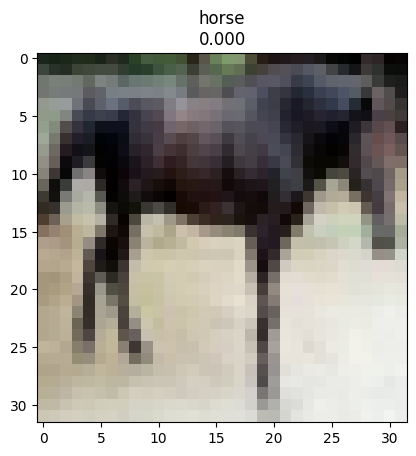

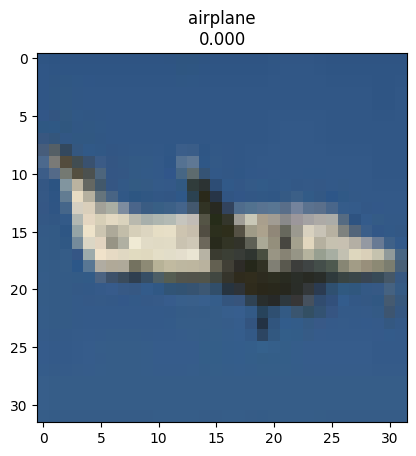

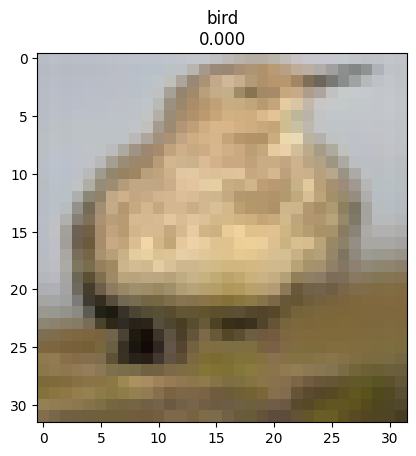

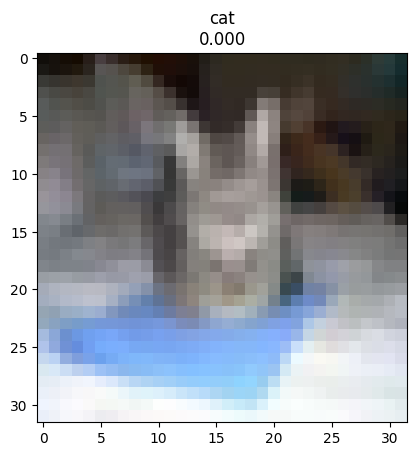

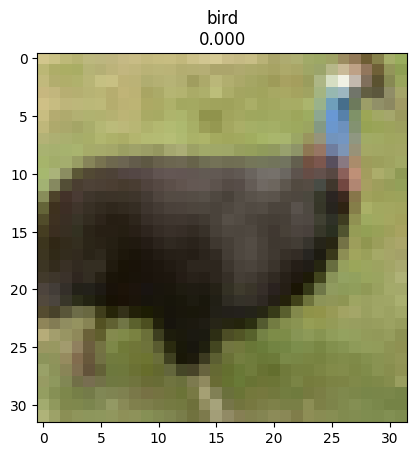

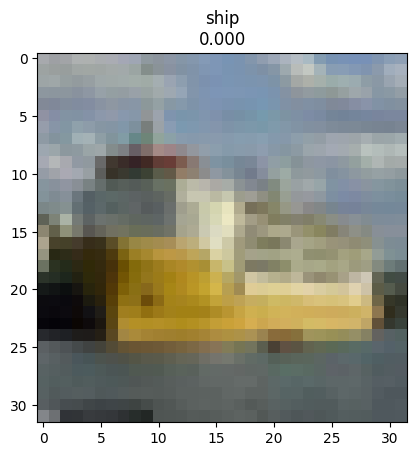

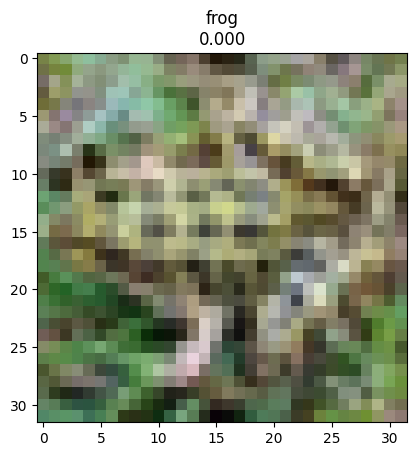

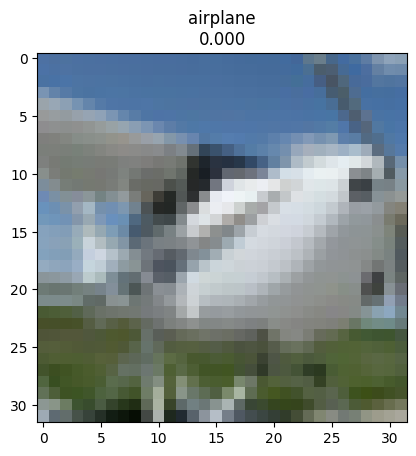

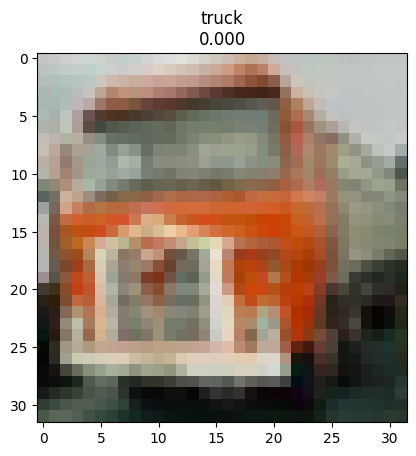

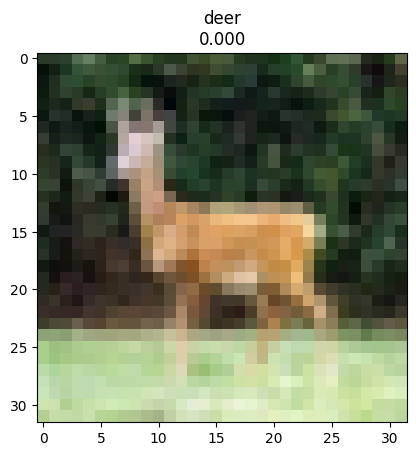

In [ ]:
img_plot(low_idx)

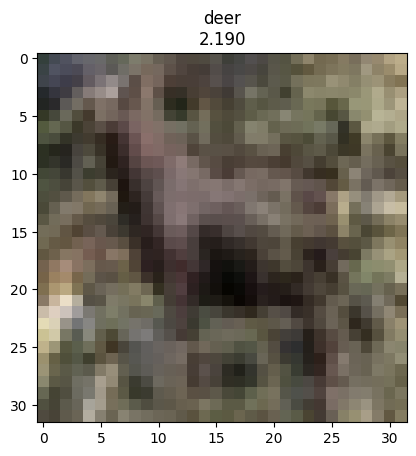

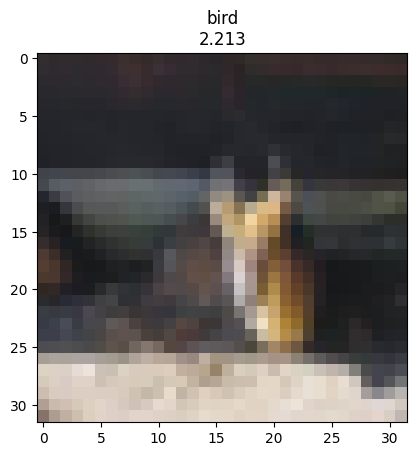

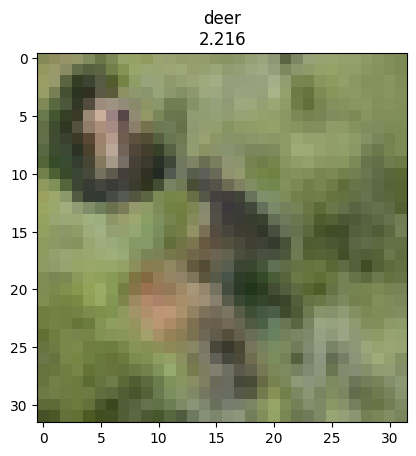

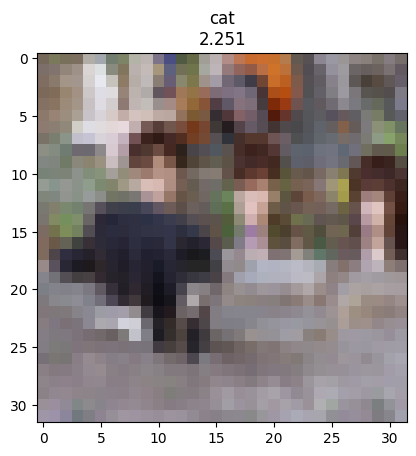

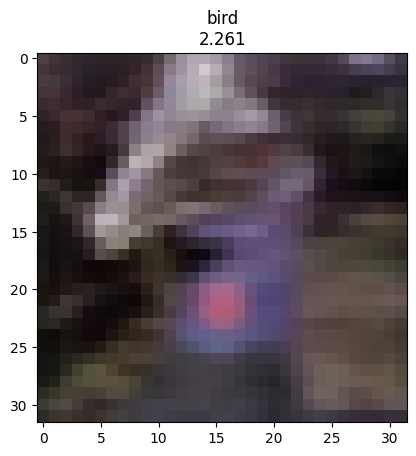

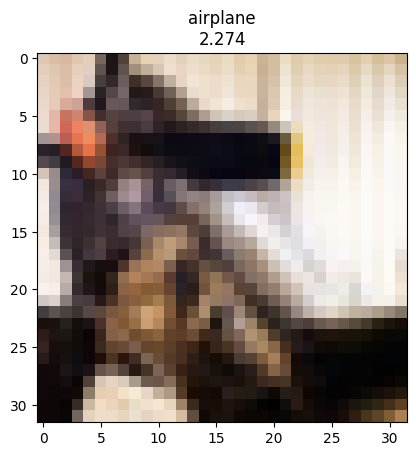

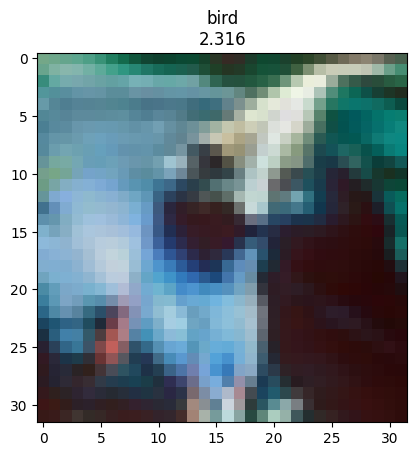

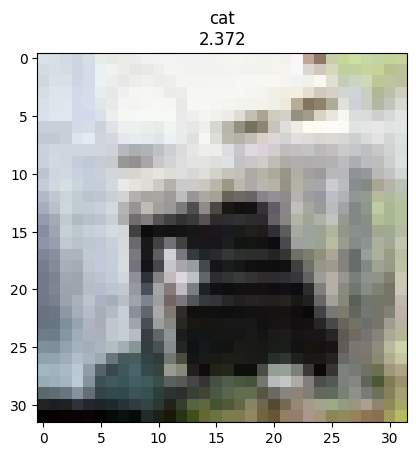

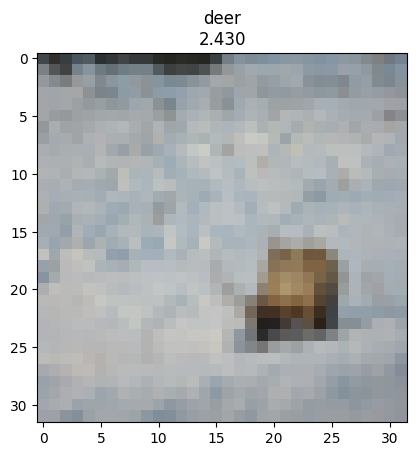

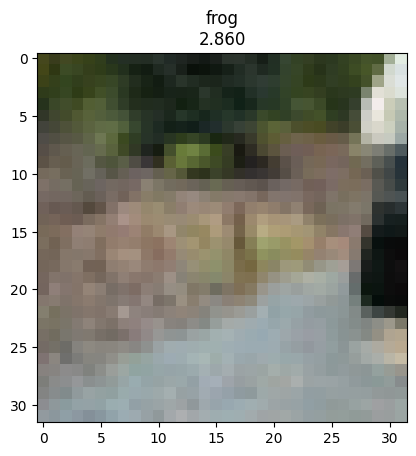

In [ ]:
img_plot(high_idx)

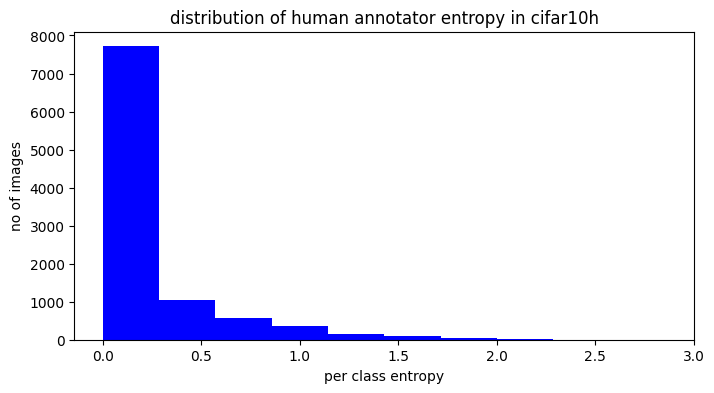

In [ ]:
#visuavilzation

plt.figure(figsize=(8,4))
plt.hist(entropy_,color='blue')
plt.xlabel('per class entropy')
plt.ylabel('no of images')
plt.title('distribution of human annotator entropy in cifar10h')
plt.show()

In [ ]:
y_test_hard.shape

(10000,)

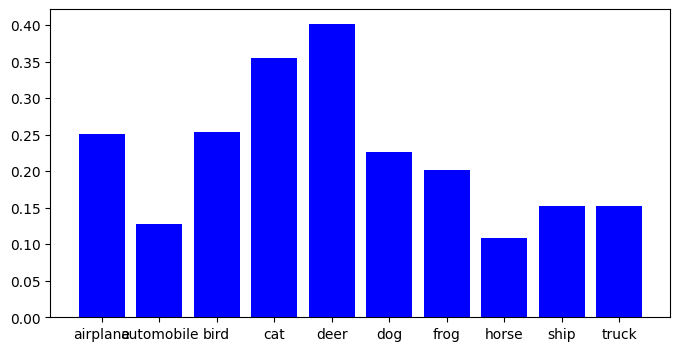

In [ ]:
#per class
class_entropy=[]
for i in range(10):
  idx=np.where(y_test_hard==i)
  class_entropy.append(entropy_[idx].mean())
plt.figure(figsize=(8,4))
plt.bar(classes,class_entropy,color='blue')
plt.show()

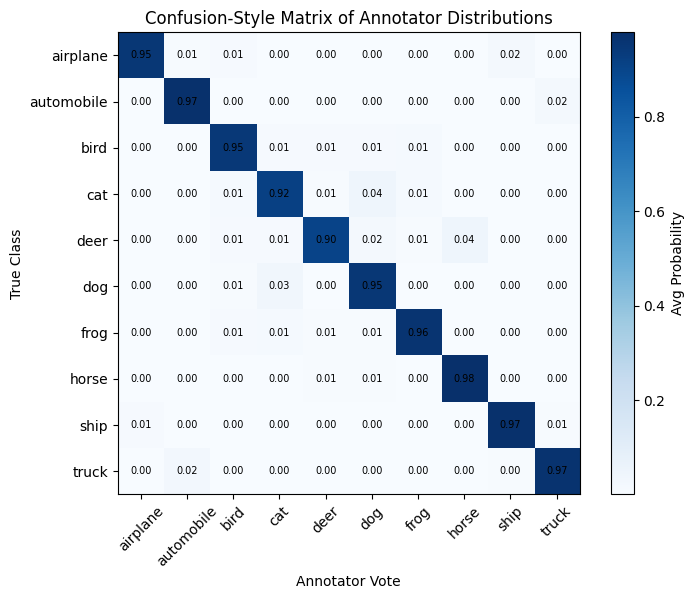

In [ ]:
#confusion matrix

# Each row = true class, each col = avg probability assigned to that class
confusion = np.zeros((10, 10))
for c in range(10):
    idx = np.where(y_test_hard == c)[0]
    confusion[c] = soft_labels[idx].mean(axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(confusion, cmap='Blues')
plt.colorbar(label='Avg Probability')
plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)
plt.xlabel("Annotator Vote")
plt.ylabel("True Class")
plt.title("Confusion-Style Matrix of Annotator Distributions")
for i in range(10):
    for j in range(10):
        plt.text(j, i, f"{confusion[i,j]:.2f}", ha='center', va='center', fontsize=7)
plt.show()

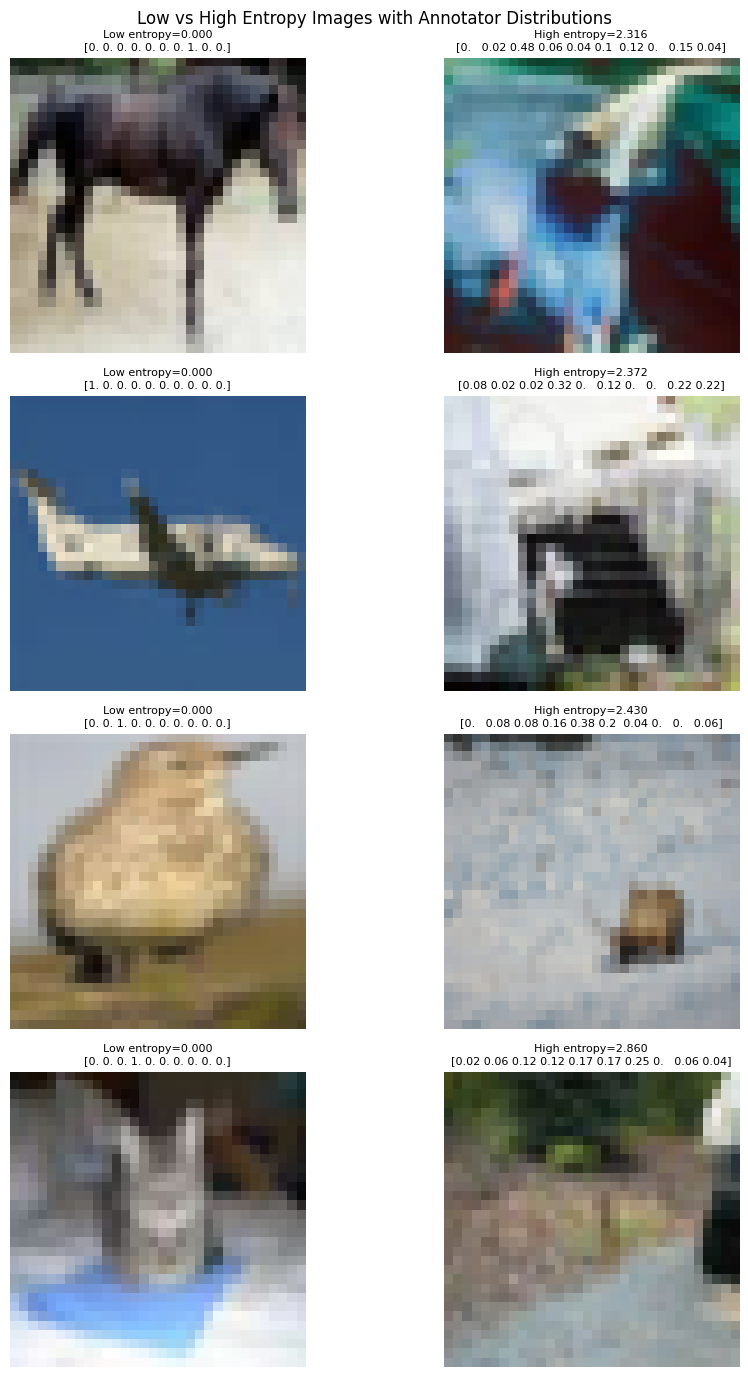

In [ ]:
low_idx  = np.argsort(entropy_)[:4]
high_idx = np.argsort(entropy_)[-4:]

fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for row, (l, h) in enumerate(zip(low_idx, high_idx)):

    # low entropy image
    axes[row, 0].imshow(X_test_hard[l])
    axes[row, 0].set_title(f"Low entropy={entropy_[l]:.3f}\n{np.round(soft_labels[l], 2)}", fontsize=8)
    axes[row, 0].axis('off')

    # high entropy image
    axes[row, 1].imshow(X_test_hard[h])
    axes[row, 1].set_title(f"High entropy={entropy_[h]:.3f}\n{np.round(soft_labels[h], 2)}", fontsize=8)
    axes[row, 1].axis('off')

plt.suptitle("Low vs High Entropy Images with Annotator Distributions", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#custom cnn model
custom_cnn=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10,activation='softmax')
])
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,978 (2.49 MB)

 Trainable params: 651,978 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

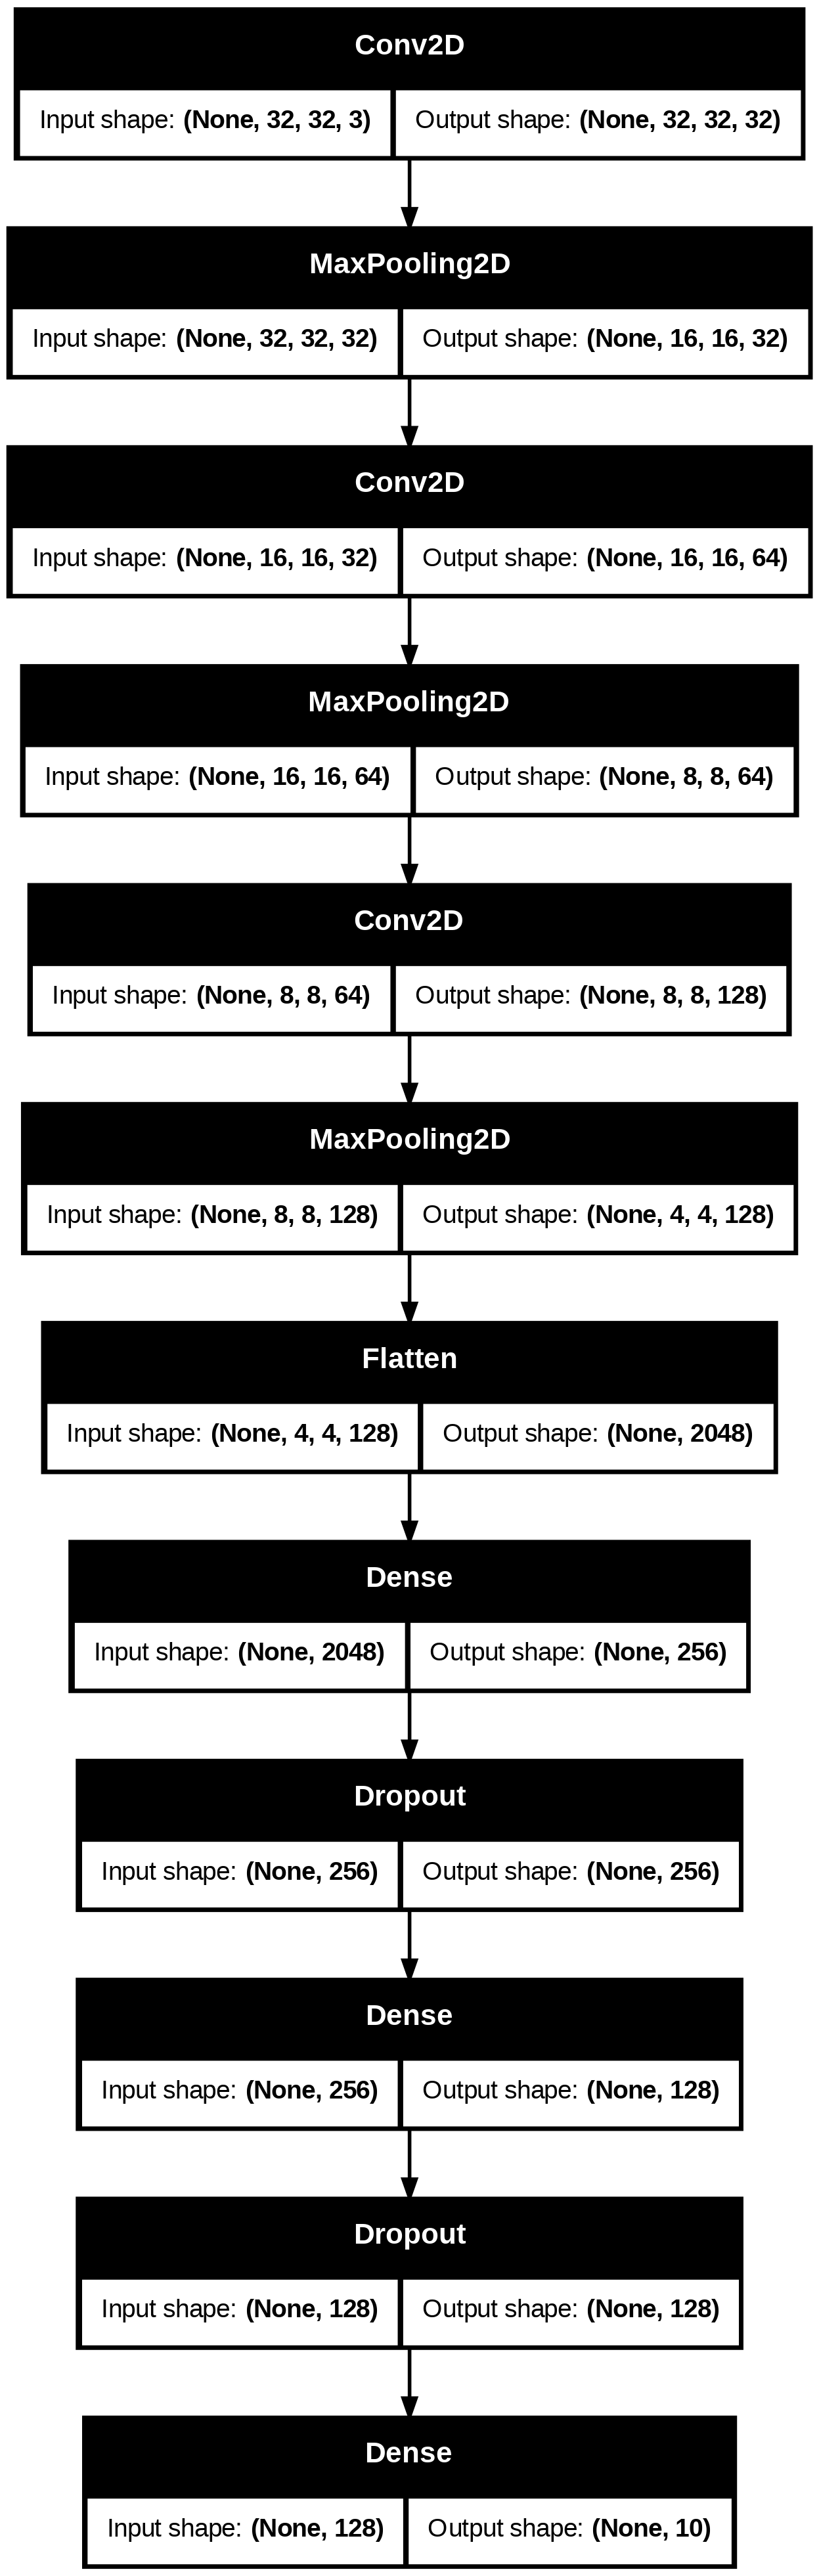

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(custom_cnn, show_shapes=True, to_file="model.png")

In [ ]:
#resnet 20
def residual_block(x,filters,downsample=False):
  shortcut=x
  stride=2 if downsample else 1

  x = layers.Conv2D(filters, (3,3), strides=stride, padding='same')(x)
  x = layers.BatchNormalization()(x)
  x = layers.ReLU()(x)

  x = layers.Conv2D(filters, (3,3), strides=1, padding='same')(x)
  x = layers.BatchNormalization()(x)

  if downsample:
      shortcut = layers.Conv2D(filters, (1,1), strides=2)(shortcut)
      shortcut = layers.BatchNormalization()(shortcut)

  x = layers.Add()([x, shortcut])
  x = layers.ReLU()(x)
  return x

In [ ]:
from tensorflow.keras import Input
def build_resnet20(input_shape=(32,32,3), num_classes=10):

    inputs = Input(shape=input_shape)

    # First layer — small conv for 32x32
    x = layers.Conv2D(16, (3,3), strides=1, padding='same')(inputs)
    x = layers.BatchNormalization()(x) #transforms activation function before passing forward
    x = layers.ReLU()(x)

    # Stage 1 — 16 filters (3 blocks)
    x = residual_block(x, 16)
    x = residual_block(x, 16)
    x = residual_block(x, 16)

    # Stage 2 — 32 filters (3 blocks)
    x = residual_block(x, 32, downsample=True)
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # Stage 3 — 64 filters (3 blocks)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)

    # MLP Head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

In [ ]:
resnet_model = build_resnet20()
resnet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │        448 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │      2,320 │ re_lu_19[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │      2,320 │ re_lu_20[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │ re_lu_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 32, 32,    │          0 │ add_9[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 32, 32,    │      2,320 │ re_lu_21[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 32, 32,    │      2,320 │ re_lu_22[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 325,002 (1.24 MB)

 Trainable params: 323,434 (1.23 MB)

 Non-trainable params: 1,568 (6.12 KB)

In [ ]:
#loss function
kl_loss=tf.keras.losses.KLDivergence()
ce_loss = tf.keras.losses.CategoricalCrossentropy()
def kl_entropy_loss(y_true, y_pred, lambda_=0.5):
    kl = tf.keras.losses.KLDivergence()
    kl_val = kl(y_true, y_pred)
    true_entropy = -tf.reduce_sum(y_true * tf.math.log(y_true + 1e-10) / tf.math.log(2.0), axis=-1)
    pred_entropy = -tf.reduce_sum(y_pred * tf.math.log(y_pred + 1e-10) / tf.math.log(2.0), axis=-1)
    entropy_penalty = tf.reduce_mean(tf.square(true_entropy - pred_entropy))
    return kl_val + lambda_ * entropy_penalty

In [ ]:
#data agumentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,   # random crop effect
    height_shift_range=0.1
)

In [ ]:
#callbacks
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

def get_callbacks(model_name):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    checkpoint = ModelCheckpoint(
        filepath=f'{model_name}_best.keras',
        monitor='val_loss',
        save_best_only=True
    )
    return [early_stop, checkpoint]

In [ ]:
#pre traning
y_train_one_hot=tf.keras.utils.to_categorical(y_train_hard,10)


# split hard labels for proper validation during pretraining
X_hard_train, X_hard_val, y_hard_train, y_hard_val = train_test_split(X_train_hard, y_train_one_hot, test_size=0.1, random_state=42)
# pretrain ResNet-20
resnet_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_resnet_pretrain = resnet_model.fit(
    datagen.flow(X_hard_train, y_hard_train, batch_size=64),
    epochs=50,
    validation_data=(X_hard_val, y_hard_val),
    callbacks=get_callbacks('resnet20_pretrain'),
    verbose=1
)

# pretrain Custom CNN
custom_cnn.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_custom_pretrain = custom_cnn.fit(
    datagen.flow(X_hard_train, y_hard_train, batch_size=64),
    epochs=50,
    validation_data=(X_hard_val, y_hard_val),
    callbacks=get_callbacks('customcnn_pretrain'),
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 83ms/step - accuracy: 0.4008 - loss: 1.6194 - val_accuracy: 0.4064 - val_loss: 1.9279
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5762 - loss: 1.1903 - val_accuracy: 0.5780 - val_loss: 1.1556
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.6415 - loss: 1.0239 - val_accuracy: 0.6076 - val_loss: 1.1230
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.6853 - loss: 0.9052 - val_accuracy: 0.6258 - val_loss: 1.0692
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7154 - loss: 0.8331 - val_accuracy: 0.6968 - val_loss: 0.8806
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7395 - loss: 0.7703 - val_accuracy: 0.7412 - val_loss: 0.7345
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7574 - loss: 0.7150 - val_accuracy: 0.7118 - val_loss: 0.8441
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.7724 - loss: 0.6753 - 

In [ ]:
#saving weights
resnet_model.save_weights('resnet20_pretrained_weights.weights.h5')
custom_cnn.save_weights('customcnn_pretrained_weights.weights.h5')
print("Pretrained weights saved!")

Pretrained weights saved!


In [ ]:
resnet_model.load_weights('resnet20_pretrained_weights.weights.h5')
#kl divergance loss

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=kl_loss,
    metrics=[tf.keras.metrics.KLDivergence()]
)

history_resnet_kl = resnet_model.fit(
    X_soft_train, y_soft_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_soft_val, y_soft_val),
    callbacks=get_callbacks('resnet20_kl'),
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 201ms/step - kl_divergence: 0.4209 - loss: 0.4209 - val_kl_divergence: 0.3844 - val_loss: 0.3844
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_divergence: 0.3633 - loss: 0.3633 - val_kl_divergence: 0.3549 - val_loss: 0.3549
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - kl_divergence: 0.3286 - loss: 0.3286 - val_kl_divergence: 0.3398 - val_loss: 0.3398
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - kl_divergence: 0.3096 - loss: 0.3096 - val_kl_divergence: 0.3321 - val_loss: 0.3321
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_divergence: 0.2872 - loss: 0.2872 - val_kl_divergence: 0.3284 - val_loss: 0.3284
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_divergence: 0.2723 - loss: 0.2723 - val_kl_divergence: 0.3248 - val_loss: 0.3248
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_divergence: 0.2604 - loss: 0.2604 - val_kl_divergence: 0.3279 - val_loss: 0.3279
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
#crross entropy loss
resnet_model.load_weights('resnet20_pretrained_weights.weights.h5')

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=ce_loss,
    metrics=[tf.keras.metrics.KLDivergence()]
)

history_resnet_ce = resnet_model.fit(
    X_soft_train, y_soft_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_soft_val, y_soft_val),
    callbacks=get_callbacks('resnet20_ce'),
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 189ms/step - kl_divergence: 0.4215 - loss: 0.5852 - val_kl_divergence: 0.3777 - val_loss: 0.5333
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - kl_divergence: 0.3557 - loss: 0.5163 - val_kl_divergence: 0.3480 - val_loss: 0.5019
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - kl_divergence: 0.3266 - loss: 0.4857 - val_kl_divergence: 0.3355 - val_loss: 0.4887
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - kl_divergence: 0.3054 - loss: 0.4642 - val_kl_divergence: 0.3290 - val_loss: 0.4818
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_divergence: 0.2897 - loss: 0.4480 - val_kl_divergence: 0.3290 - val_loss: 0.4815
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_divergence: 0.2699 - loss: 0.4281 - val_kl_divergence: 0.3235 - val_loss: 0.4760
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_divergence: 0.2584 - loss: 0.4162 - val_kl_divergence: 0.3247 - val_loss: 0.4772
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
#custom loss
resnet_model.load_weights('resnet20_pretrained_weights.weights.h5')

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=kl_entropy_loss,
    metrics=[tf.keras.metrics.KLDivergence()]
)

history_resnet_custom = resnet_model.fit(
    X_soft_train, y_soft_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_soft_val, y_soft_val),
    callbacks=get_callbacks('resnet20_custom'),
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 188ms/step - kl_divergence: 0.4388 - loss: 0.6300 - val_kl_divergence: 0.4103 - val_loss: 0.5665
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - kl_divergence: 0.3913 - loss: 0.5555 - val_kl_divergence: 0.3951 - val_loss: 0.5431
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_divergence: 0.3647 - loss: 0.5243 - val_kl_divergence: 0.3899 - val_loss: 0.5339
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - kl_divergence: 0.3455 - loss: 0.4947 - val_kl_divergence: 0.3886 - val_loss: 0.5297
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - kl_divergence: 0.3153 - loss: 0.4521 - val_kl_divergence: 0.3906 - val_loss: 0.5254
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_divergence: 0.3064 - loss: 0.4369 - val_kl_divergence: 0.3884 - val_loss: 0.5212
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_divergence: 0.2946 - loss: 0.4188 - val_kl_divergence: 0.3935 - val_loss: 0.5214
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
#fine tuning our custom cnn
#kl divergence
custom_cnn.load_weights('customcnn_pretrained_weights.weights.h5')
custom_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                   loss=kl_loss,
                   metrics=[tf.keras.metrics.KLDivergence()])
history_custom_kl = custom_cnn.fit(
    X_soft_train, y_soft_train,
    epochs=50, batch_size=64,
    validation_data=(X_soft_val, y_soft_val),
    callbacks=get_callbacks('customcnn_kl'),
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - kl_divergence: 0.6432 - loss: 0.6432 - val_kl_divergence: 0.5171 - val_loss: 0.5171
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5973 - loss: 0.5973 - val_kl_divergence: 0.5096 - val_loss: 0.5096
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5604 - loss: 0.5604 - val_kl_divergence: 0.5064 - val_loss: 0.5064
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5331 - loss: 0.5331 - val_kl_divergence: 0.5019 - val_loss: 0.5019
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5088 - loss: 0.5088 - val_kl_divergence: 0.5017 - val_loss: 0.5017
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5026 - loss: 0.5026 - val_kl_divergence: 0.5013 - val_loss: 0.5013
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.4807 - loss: 0.4807 - val_kl_divergence: 0.4998 - val_loss: 0.4998
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/s

In [ ]:
#cross entropy loss
custom_cnn.load_weights('customcnn_pretrained_weights.weights.h5')
custom_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                   loss=ce_loss,
                   metrics=[tf.keras.metrics.KLDivergence()])
history_custom_ce = custom_cnn.fit(
    X_soft_train, y_soft_train,
    epochs=50, batch_size=64,
    validation_data=(X_soft_val, y_soft_val),
    callbacks=get_callbacks('customcnn_ce'),
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - kl_divergence: 0.6424 - loss: 0.8079 - val_kl_divergence: 0.5184 - val_loss: 0.6750
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_divergence: 0.5891 - loss: 0.7522 - val_kl_divergence: 0.5093 - val_loss: 0.6648
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5663 - loss: 0.7281 - val_kl_divergence: 0.5084 - val_loss: 0.6635
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5316 - loss: 0.6927 - val_kl_divergence: 0.5014 - val_loss: 0.6562
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_divergence: 0.5203 - loss: 0.6814 - val_kl_divergence: 0.5024 - val_loss: 0.6570
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5027 - loss: 0.6636 - val_kl_divergence: 0.5003 - val_loss: 0.6548
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - kl_divergence: 0.4848 - loss: 0.6455 - val_kl_divergence: 0.4992 - val_loss: 0.6537
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13m

In [ ]:
#custom loss
custom_cnn.load_weights('customcnn_pretrained_weights.weights.h5')
custom_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                   loss=kl_entropy_loss,
                   metrics=[tf.keras.metrics.KLDivergence()])
history_custom_custom = custom_cnn.fit(
    X_soft_train, y_soft_train,
    epochs=50, batch_size=64,
    validation_data=(X_soft_val, y_soft_val),
    callbacks=get_callbacks('customcnn_custom'),
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - kl_divergence: 0.6746 - loss: 1.0452 - val_kl_divergence: 0.5545 - val_loss: 0.8645
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - kl_divergence: 0.6599 - loss: 0.9749 - val_kl_divergence: 0.5603 - val_loss: 0.8473
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_divergence: 0.6386 - loss: 0.9212 - val_kl_divergence: 0.5603 - val_loss: 0.8329
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.6156 - loss: 0.8783 - val_kl_divergence: 0.5718 - val_loss: 0.8365
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5799 - loss: 0.8283 - val_kl_divergence: 0.5690 - val_loss: 0.8247
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5799 - loss: 0.8189 - val_kl_divergence: 0.5706 - val_loss: 0.8241
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_divergence: 0.5511 - loss: 0.7823 - val_kl_divergence: 0.5643 - val_loss: 0.8170
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms

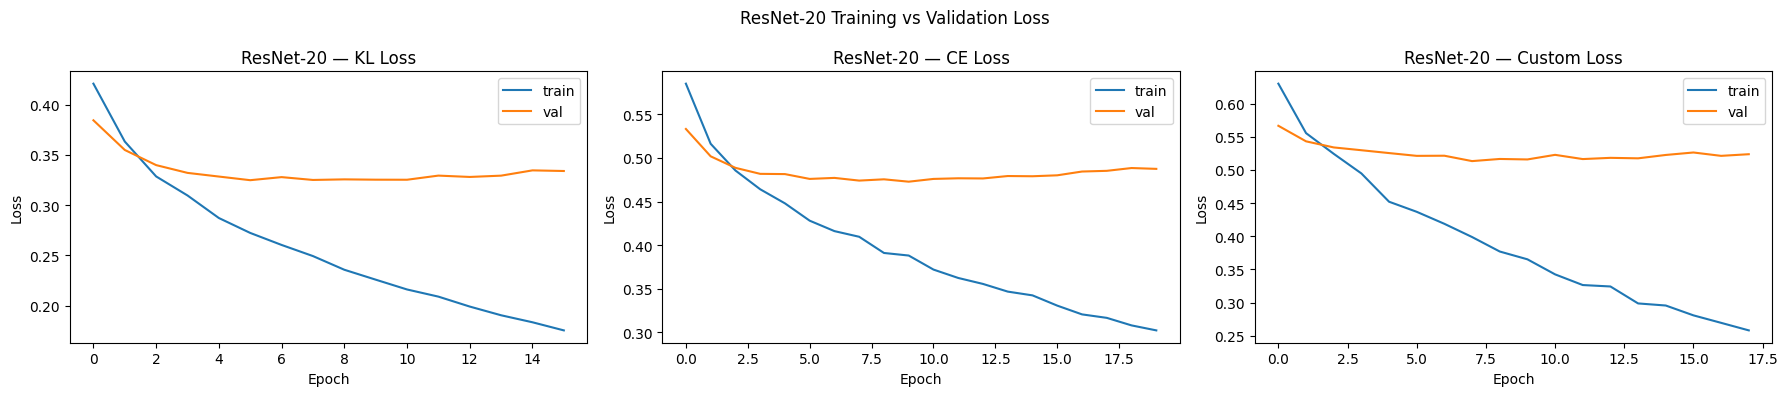

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_resnet_kl.history['loss'], label='train')
axes[0].plot(history_resnet_kl.history['val_loss'], label='val')
axes[0].set_title("ResNet-20 — KL Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_resnet_ce.history['loss'], label='train')
axes[1].plot(history_resnet_ce.history['val_loss'], label='val')
axes[1].set_title("ResNet-20 — CE Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(history_resnet_custom.history['loss'], label='train')
axes[2].plot(history_resnet_custom.history['val_loss'], label='val')
axes[2].set_title("ResNet-20 — Custom Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.suptitle("ResNet-20 Training vs Validation Loss")
plt.tight_layout()
plt.show()

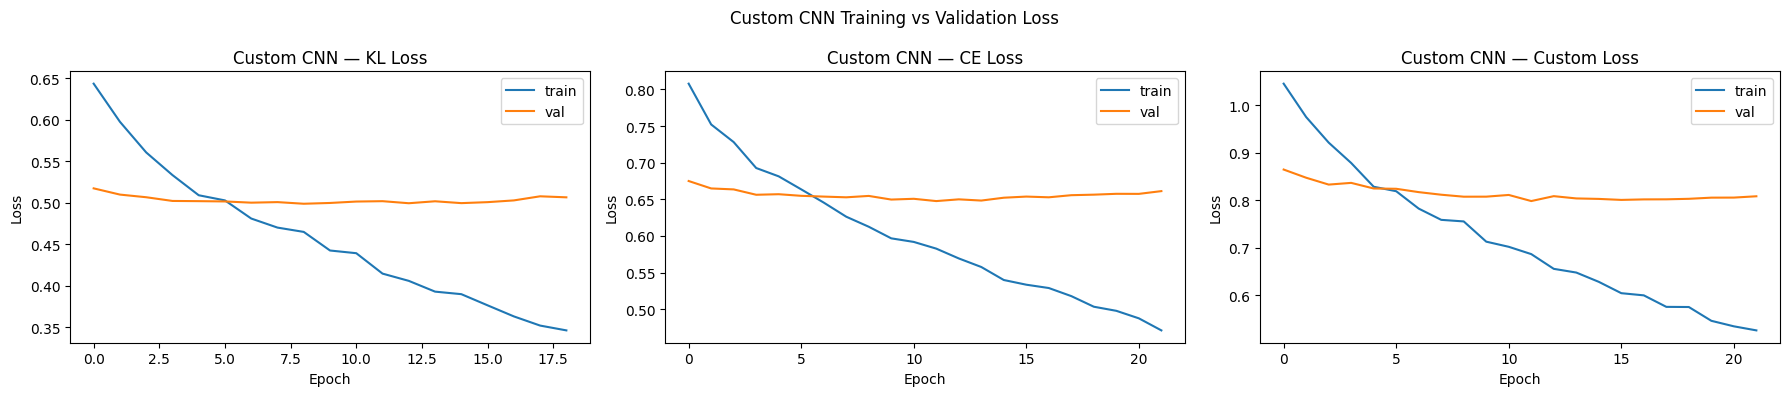

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_custom_kl.history['loss'], label='train')
axes[0].plot(history_custom_kl.history['val_loss'], label='val')
axes[0].set_title("Custom CNN — KL Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_custom_ce.history['loss'], label='train')
axes[1].plot(history_custom_ce.history['val_loss'], label='val')
axes[1].set_title("Custom CNN — CE Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(history_custom_custom.history['loss'], label='train')
axes[2].plot(history_custom_custom.history['val_loss'], label='val')
axes[2].set_title("Custom CNN — Custom Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.suptitle("Custom CNN Training vs Validation Loss")
plt.tight_layout()
plt.show()

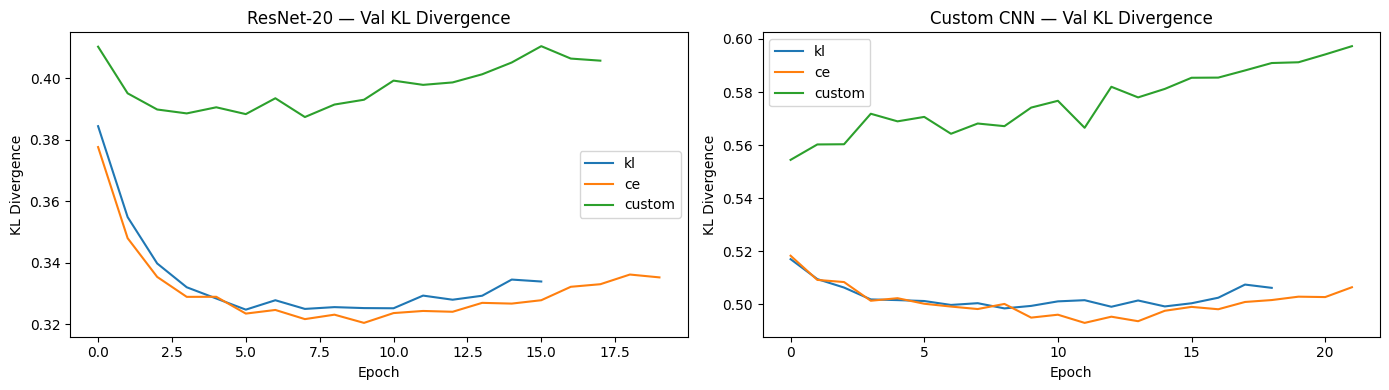

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ResNet-20
axes[0].plot(history_resnet_kl.history['val_kl_divergence'],     label='kl')
axes[0].plot(history_resnet_ce.history['val_kl_divergence'],     label='ce')
axes[0].plot(history_resnet_custom.history['val_kl_divergence'], label='custom')
axes[0].set_title("ResNet-20 — Val KL Divergence")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("KL Divergence")
axes[0].legend()

# Custom CNN
axes[1].plot(history_custom_kl.history['val_kl_divergence'],     label='kl')
axes[1].plot(history_custom_ce.history['val_kl_divergence'],     label='ce')
axes[1].plot(history_custom_custom.history['val_kl_divergence'], label='custom')
axes[1].set_title("Custom CNN — Val KL Divergence")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("KL Divergence")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#summary
print(f"{'Model':<15} {'Loss':<10} {'Best Val Loss':>15} {'Best Val KL':>12}")
print("-" * 55)

histories = {
    'ResNet-20 KL'    : history_resnet_kl,
    'ResNet-20 CE'    : history_resnet_ce,
    'ResNet-20 Custom': history_resnet_custom,
    'CustomCNN KL'    : history_custom_kl,
    'CustomCNN CE'    : history_custom_ce,
    'CustomCNN Custom': history_custom_custom
}

for name, h in histories.items():
    best_val_loss = min(h.history['val_loss'])
    best_val_kl   = min(h.history['val_kl_divergence'])
    print(f"{name:<25} {best_val_loss:>15.4f} {best_val_kl:>12.4f}")

Model           Loss         Best Val Loss  Best Val KL
-------------------------------------------------------
ResNet-20 KL                       0.3248       0.3248
ResNet-20 CE                       0.4728       0.3205
ResNet-20 Custom                   0.5133       0.3874
CustomCNN KL                       0.4985       0.4985
CustomCNN CE                       0.6476       0.4931
CustomCNN Custom                   0.7982       0.5545


In [ ]:
#predicting
# Load best saved weights for each model before predicting
resnet_model.load_weights('resnet20_kl_best.keras')
y_pred_resnet_kl = resnet_model.predict(X_soft_test)

resnet_model.load_weights('resnet20_ce_best.keras')
y_pred_resnet_ce = resnet_model.predict(X_soft_test)

resnet_model.load_weights('resnet20_custom_best.keras')
y_pred_resnet_custom = resnet_model.predict(X_soft_test)

custom_cnn.load_weights('customcnn_kl_best.keras')
y_pred_custom_kl = custom_cnn.predict(X_soft_test)

custom_cnn.load_weights('customcnn_ce_best.keras')
y_pred_custom_ce = custom_cnn.predict(X_soft_test)

custom_cnn.load_weights('customcnn_custom_best.keras')
y_pred_custom_custom = custom_cnn.predict(X_soft_test)

print("All predictions done!")
print("Shape:", y_pred_resnet_kl.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
All predictions done!
Shape: (2000, 10)


In [ ]:
(y_pred_resnet_kl[105])

array([0.74396884, 0.00261799, 0.06805047, 0.03799268, 0.0130856 ,
       0.01368462, 0.0022066 , 0.02518955, 0.09132867, 0.00187506],
      dtype=float32)

In [ ]:
y_pred_resnet_ce[105]

array([0.70094514, 0.00511025, 0.07076658, 0.05272621, 0.01180799,
       0.01671119, 0.00328915, 0.02481315, 0.1111907 , 0.00263971],
      dtype=float32)

In [ ]:
y_soft_test[105]

array([0.06122449, 0.        , 0.81632656, 0.        , 0.04081633,
       0.        , 0.04081633, 0.02040816, 0.02040816, 0.        ],
      dtype=float32)

In [ ]:
from scipy.special import rel_entr
from scipy.spatial.distance import jensenshannon
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def compute_distribution_metrics(y_true, y_pred):

    # KL Divergence (using scipy rel_entr)
    kl_vals = np.sum(rel_entr(y_true, y_pred), axis=1)

    # Jensen-Shannon Divergence
    jsd_vals = np.array([
        jensenshannon(y_true[i], y_pred[i])**2
        for i in range(len(y_true))
    ])

    # Cosine Similarity
    cos_vals = np.array([
        cosine_similarity(y_true[i].reshape(1,-1),
                          y_pred[i].reshape(1,-1))[0][0]
        for i in range(len(y_true))
    ])

    return {
        'KL Mean'  : kl_vals.mean(),  'KL Std'  : kl_vals.std(),
        'JSD Mean' : jsd_vals.mean(), 'JSD Std' : jsd_vals.std(),
        'Cos Mean' : cos_vals.mean(), 'Cos Std' : cos_vals.std()
    }

In [ ]:
from scipy.stats import entropy as scipy_entropy
from scipy.stats import pearsonr, spearmanr

def compute_entropy_metrics(y_true, y_pred):
    true_entropy = scipy_entropy(y_true.T, base=2)
    pred_entropy = scipy_entropy(y_pred.T, base=2)

    pearson  = pearsonr(true_entropy, pred_entropy)[0]
    spearman = spearmanr(true_entropy, pred_entropy)[0]

    return {
        'Pearson' : pearson,
        'Spearman': spearman,
        'true_entropy': true_entropy,
        'pred_entropy': pred_entropy
    }

In [ ]:
def precision_at_k(y_true, y_pred, k):
    true_entropy = scipy_entropy(y_true.T, base=2)
    pred_entropy = scipy_entropy(y_pred.T, base=2)

    true_top_k = set(np.argsort(true_entropy)[-k:])
    pred_top_k = set(np.argsort(pred_entropy)[-k:])

    return len(true_top_k & pred_top_k) / k

def compute_precision_at_k(y_true, y_pred):
    return {
        'P@100': precision_at_k(y_true, y_pred, 100),
        'P@200': precision_at_k(y_true, y_pred, 200),
        'P@500': precision_at_k(y_true, y_pred, 500)
    }

In [ ]:
models = {
    'ResNet-20 KL'    : y_pred_resnet_kl,
    'ResNet-20 CE'    : y_pred_resnet_ce,
    'ResNet-20 Custom': y_pred_resnet_custom,
    'CustomCNN KL'    : y_pred_custom_kl,
    'CustomCNN CE'    : y_pred_custom_ce,
    'CustomCNN Custom': y_pred_custom_custom
}

rows = []
for name, y_pred in models.items():
    dist  = compute_distribution_metrics(y_soft_test, y_pred)
    entr  = compute_entropy_metrics(y_soft_test, y_pred)
    prec  = compute_precision_at_k(y_soft_test, y_pred)

    rows.append({
        'Model'    : name,
        'KL'       : f"{dist['KL Mean']:.4f} ± {dist['KL Std']:.4f}",
        'JSD'      : f"{dist['JSD Mean']:.4f} ± {dist['JSD Std']:.4f}",
        'Cosine'   : f"{dist['Cos Mean']:.4f} ± {dist['Cos Std']:.4f}",
        'Pearson'  : f"{entr['Pearson']:.4f}",
        'Spearman' : f"{entr['Spearman']:.4f}",
        'P@100'    : f"{prec['P@100']:.4f}",
        'P@200'    : f"{prec['P@200']:.4f}",
        'P@500'    : f"{prec['P@500']:.4f}"
    })

df = pd.DataFrame(rows).set_index('Model')
print(df.to_string())

/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:1388: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)
/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:1388: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


                               KL              JSD           Cosine Pearson Spearman   P@100   P@200   P@500
Model                                                                                                       
ResNet-20 KL      0.3273 ± 0.6894  0.0700 ± 0.1278  0.9133 ± 0.2143  0.4213   0.3966  0.1800  0.3150  0.5100
ResNet-20 CE      0.3250 ± 0.7052  0.0697 ± 0.1287  0.9126 ± 0.2166  0.4172   0.3990  0.1900  0.2950  0.5160
ResNet-20 Custom  0.3890 ± 0.9160        nan ± nan  0.9108 ± 0.2313  0.4031   0.3955  0.1700  0.2950  0.5100
CustomCNN KL      0.5099 ± 0.8133  0.1173 ± 0.1582  0.8526 ± 0.2627  0.3272   0.3231  0.0900  0.2150  0.4020
CustomCNN CE      0.5058 ± 0.8087  0.1166 ± 0.1586  0.8528 ± 0.2641  0.3253   0.3236  0.1200  0.1950  0.4100
CustomCNN Custom  0.6055 ± 1.1803        nan ± nan  0.8530 ± 0.2905  0.3074   0.3233  0.1500  0.2200  0.4260


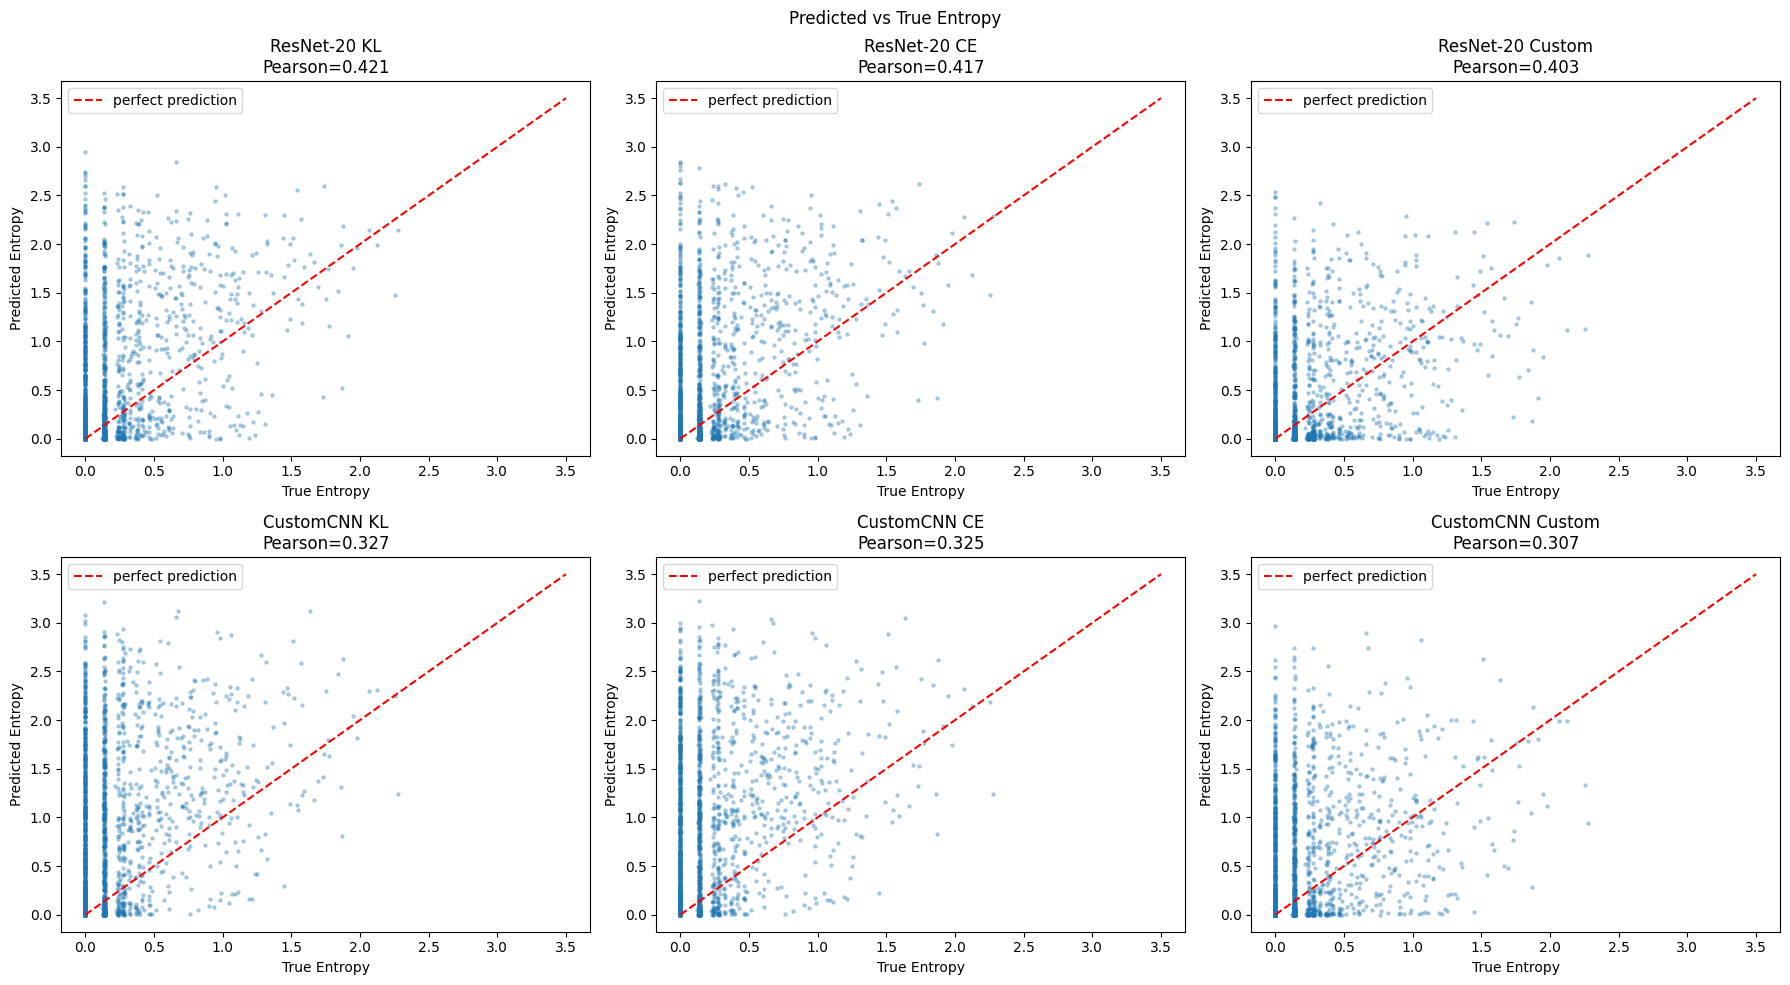

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(models.items()):
    entr = compute_entropy_metrics(y_soft_test, y_pred)
    axes[i].scatter(entr['true_entropy'], entr['pred_entropy'], alpha=0.3, s=5)
    axes[i].plot([0, 3.5], [0, 3.5], 'r--', label='perfect prediction')
    axes[i].set_xlabel("True Entropy")
    axes[i].set_ylabel("Predicted Entropy")
    axes[i].set_title(f"{name}\nPearson={entr['Pearson']:.3f}")
    axes[i].legend()

plt.suptitle("Predicted vs True Entropy")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:1388: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)
/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:1388: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)
/tmp/ipykernel_2433/2477270510.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df_raw.index, rotation=45, ha='right')
/tmp/ipykernel_2433/2477270510.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df_raw.index, rotation=45, ha='right')
/tmp/ipykernel_2433/2477270510.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df_raw.index, rotation=45, ha='right')


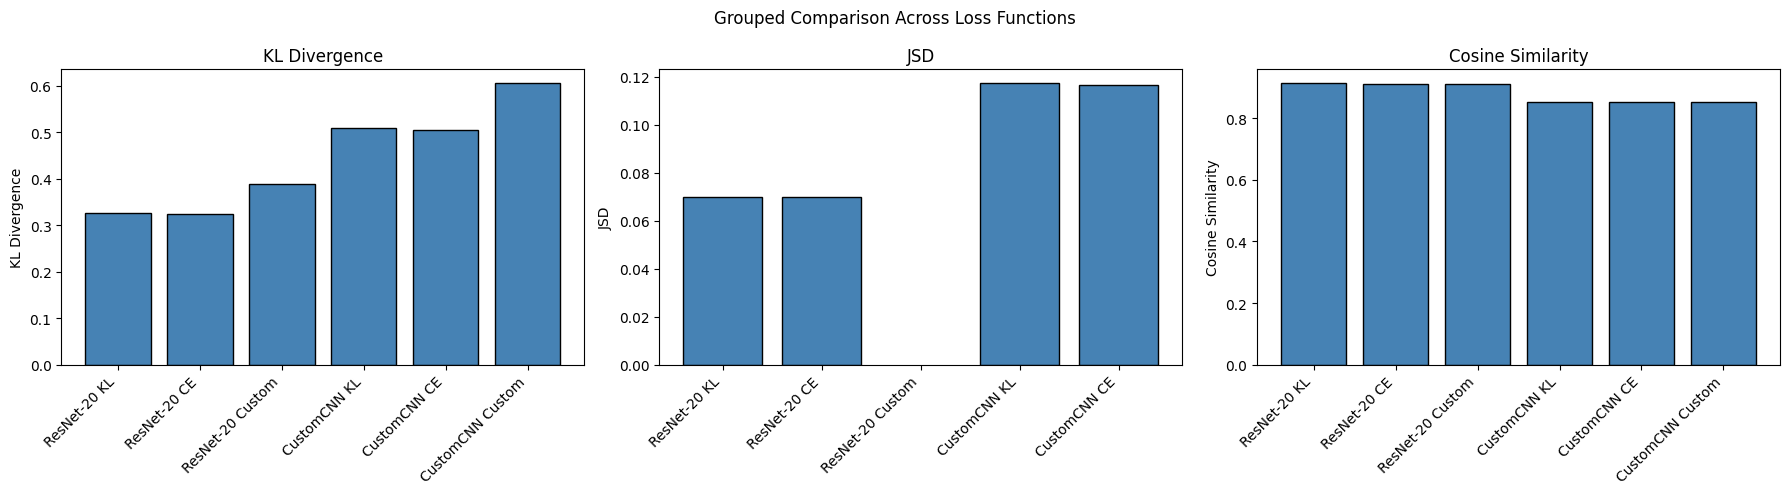

In [ ]:
metrics_to_plot = ['KL Mean', 'JSD Mean', 'Cos Mean']
metric_labels   = ['KL Divergence', 'JSD', 'Cosine Similarity']

raw_rows = []
for name, y_pred in models.items():
    dist = compute_distribution_metrics(y_soft_test, y_pred)
    entr = compute_entropy_metrics(y_soft_test, y_pred)
    raw_rows.append({
        'Model'   : name,
        'KL Mean' : dist['KL Mean'],
        'JSD Mean': dist['JSD Mean'],
        'Cos Mean': dist['Cos Mean'],
        'Pearson' : entr['Pearson']
    })

df_raw = pd.DataFrame(raw_rows).set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    axes[i].bar(df_raw.index, df_raw[col], color='steelblue', edgecolor='black')
    axes[i].set_title(label)
    axes[i].set_ylabel(label)
    axes[i].set_xticklabels(df_raw.index, rotation=45, ha='right')

plt.suptitle("Grouped Comparison Across Loss Functions")
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


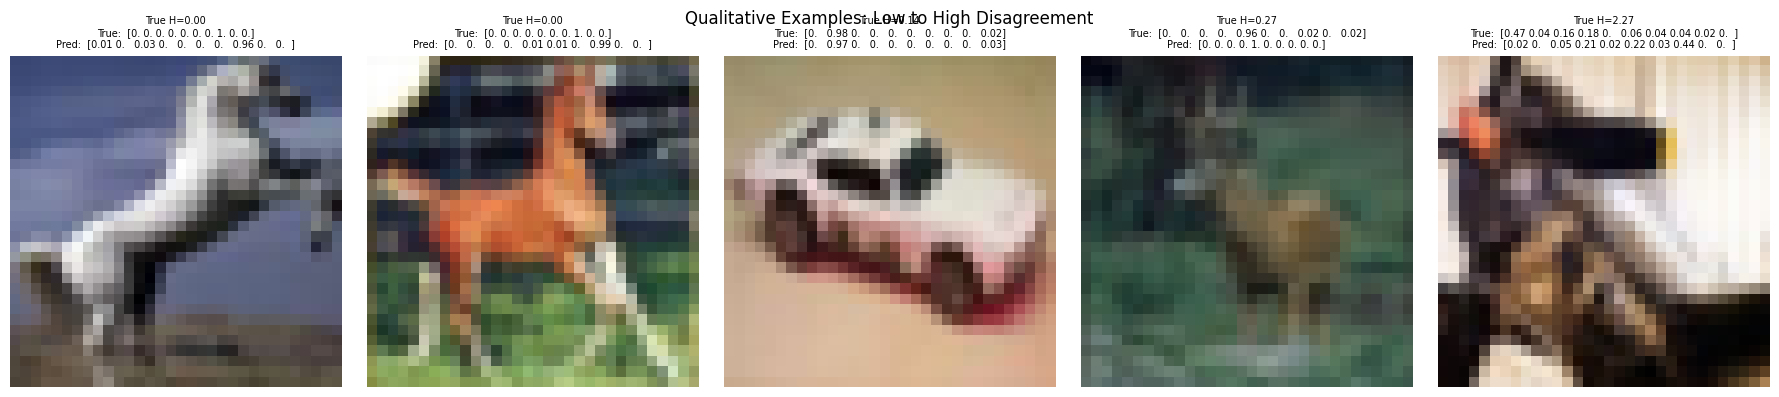

In [ ]:
# Use best model (resnet_kl as example — replace with your best)
resnet_model.load_weights('resnet20_kl_best.keras')
y_pred_best = resnet_model.predict(X_soft_test)

true_entropy  = scipy_entropy(y_soft_test.T, base=2)
sorted_idx    = np.argsort(true_entropy)

# pick 5 evenly spaced from low to high entropy
sample_idx = [sorted_idx[i] for i in [0, 500, 1000, 1500, 1999]]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_soft_test[idx])
    axes[i].set_title(
        f"True H={true_entropy[idx]:.2f}\n"
        f"True:  {np.round(y_soft_test[idx], 2)}\n"
        f"Pred:  {np.round(y_pred_best[idx], 2)}",
        fontsize=7
    )
    axes[i].axis('off')

plt.suptitle("Qualitative Examples: Low to High Disagreement")
plt.tight_layout()
plt.show()